#### Exercise 4

TODO:
- find the events

Before submitting:
- increase number of masses (`n_masses`)
- use better values in `bilby.run_sampler`

**Notes**

An event is described by:
- the list of detectors that found it
- its time (in each detector)
- its geocentric time (computed from one detector time)
- the mass

In [1]:
#packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import os

import numpy as np
# The first import of matplotlib can take some time (especially on cloud platforms). This is normal.
import matplotlib
import matplotlib.pyplot as plt

from pycbc.types.timeseries import TimeSeries
from pycbc.frame import read_frame
from pycbc.filter import resample_to_delta_t, highpass
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.waveform import get_td_waveform
from pycbc.filter import matched_filter
from pycbc.vetoes import power_chisq
from pycbc.events.ranking import newsnr

import bilby
from bilby.core.prior import Uniform, PowerLaw
from bilby.gw.conversion import convert_to_lal_binary_black_hole_parameters, generate_all_bbh_parameters

file_name = "challenge3.gwf"
URL = "https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf"

channel_format = "{ifo}:CHALLENGE3"

# Parameters of pre-processing steps
highpass_cutoff = 15.0
downsample_freq = 2048
strain_crop     = 2

# Parameters for PSD computation
welch_segment_length = 4

# Waveform parameters
waveform_cutoff = 20

# SNR
snr_crop = 4

# Reweighted SNR
nbins = 26
dof = nbins * 2 - 2

#source information
m_min = 10 #Msol
m_max = 50 #Msol
#recommended: mass range with logsteps between 10 and 50
spin = 0

event_duration = 8

n_masses = 10
masses_grid = np.logspace(np.log10(m_min), np.log10(m_max), n_masses)
print(masses_grid)

[10.         11.95813175 14.29969148 17.09975947 20.44811765 24.45212848
 29.24017738 34.96578934 41.81255155 50.        ]


## Read data and compute PSD

In [2]:
#downloading the data source
if not os.path.isfile(file_name):
  print("Downloading data file")
  import urllib
  urllib.request.urlretrieve(URL, file_name)
  print('Getting : {}'.format(URL))
else:
  print("No downloading")

Getting : https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf


Signal for H1: duration=4092.0s, delta_t=0.00048828125s, delta_f=0.00024437927663734115Hz (sampling rate=2048.0Hz)
Signal for L1: duration=4092.0s, delta_t=0.00048828125s, delta_f=0.00024437927663734115Hz (sampling rate=2048.0Hz)


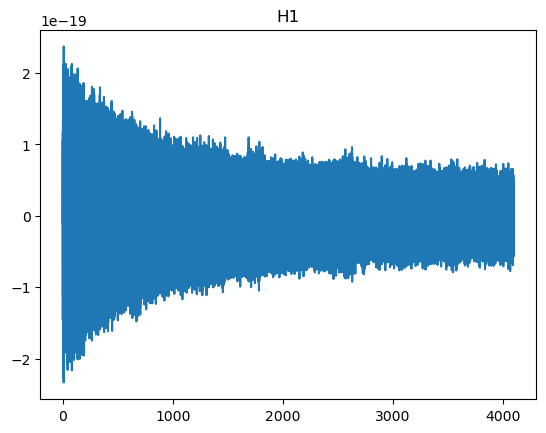

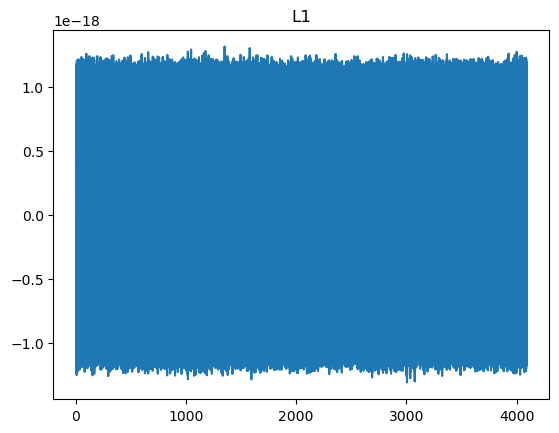

In [3]:
# Read and preprocess the data

def read_and_preprocess(file_name, ifo):
    ts = read_frame(file_name, channel_format.format(ifo=ifo))
    strain = resample_to_delta_t(
        highpass(ts, highpass_cutoff),
        1/downsample_freq
    )
    strain = strain.crop(strain_crop, strain_crop)
    return strain

data = {}
for ifo_name in ['H1', 'L1']:
    strain = read_and_preprocess(file_name, ifo_name)
    print(f"Signal for {ifo_name}: duration={strain.duration}s, delta_t={strain.delta_t}s, delta_f={strain.delta_f}Hz (sampling rate={1/strain.delta_t}Hz)")
    data[ifo_name] = strain
    plt.figure()
    strain.plot()
    plt.title(ifo_name)

In [4]:
# Compute PSD

def compute_psd(strain):
    psd = inverse_spectrum_truncation(
        interpolate(
            strain.psd(welch_segment_length),
            strain.delta_f
        ),
        int(4 * strain.sample_rate),
        low_frequency_cutoff=highpass_cutoff # Use the same cutoff
    )
    return psd


psds = {}
for ifo_name in ['H1', 'L1']:
    psd = compute_psd(data[ifo_name])
    psds[ifo_name] = psd

In [5]:
# Create the templates

def create_template(m, l):
    # Generate the template
    hp, hc = get_td_waveform(
        approximant="SEOBNRv4_opt",
        mass1=m,
        mass2=m,
        delta_t=1.0/downsample_freq,
        f_lower=waveform_cutoff
    )
    # Resize the vector to match our data
    hp.resize(l)
    # Shift template
    template = hp.cyclic_time_shift(hp.start_time)
    return template

templates = {}
l = len(data['H1'])
for m in masses_grid:
   templates[m] = create_template(m, l)

## Compute SNR

In [6]:
#once we have the template:compute the snr of each template with the data one mass at a time
def snr_computation(cond_data, template, psd):
    snr = abs(matched_filter(
        template, cond_data, psd=psd,
        low_frequency_cutoff=waveform_cutoff))
    snr = snr.crop(snr_crop + 4, snr_crop)
    return snr

#do twice what u did on one IFO
snrs = {}
for ifo_name in ['H1', 'L1']:
    #compute the SNR of all the data there
    for m in masses_grid:
        snr = snr_computation(data[ifo_name], templates[m], psds[ifo_name])
        snrs[(ifo_name, m)] = snr

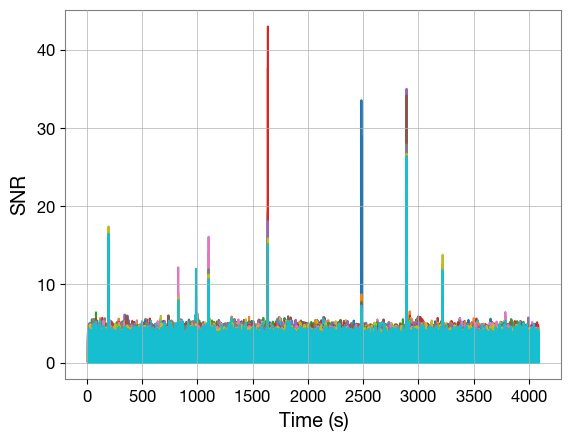

In [14]:
# Find the peaks

for ifo_name in ['H1', 'L1']:
    for m in masses_grid:
        snrs[(ifo_name, m)].plot()
        plt.xlabel("Time (s)")
        plt.ylabel("SNR");

In [8]:
# Compute reweighted SNR

def reweighted_snr(template, data, psd):
    chisq = power_chisq(template, data, nbins, psd, low_frequency_cutoff=waveform_cutoff)
    chisq = chisq.crop(snr_crop + 4, snr_crop)
    chisq /= dof
    nsnr = newsnr(snr, chisq)
    return TimeSeries(nsnr, delta_t=chisq.delta_t, epoch=chisq.sample_times[0])

nsnrs = {}
for ifo_name in ['H1', 'L1']:
    for m in masses_grid:
        nsnrs[(ifo_name, m)] = reweighted_snr(templates[m], data[ifo_name], psds[ifo_name])

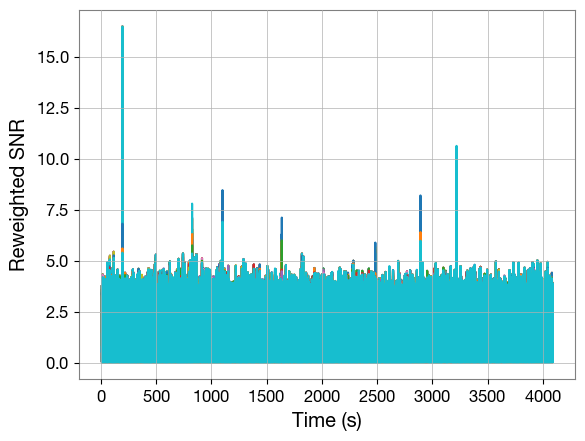

In [13]:
for ifo_name in ['H1', 'L1']:
    for m in masses_grid:
        nsnrs[(ifo_name, m)].plot()
        plt.xlabel("Time (s)")
        plt.ylabel("Reweighted SNR");

## Find events

In [10]:
# First find candidates by identifying the maxima
# From the plot, we can assume around 8 events
ref_snr = snrs[('H1', masses_grid[0])].copy()
candidates_event_times = []
while (len(candidates_event_times) < 10):
    t = ref_snr.numpy().argmax()
    print(t)
    candidates_event_times.append(t)
    ref_snr[t] = 0

5066685
5066686
5066684
5066687
5066683
5066688
5066682
5066689
5066681
5066690


## Parameter estimation

In [11]:
# Create fake events
events = [
    dict(
        name="Event 0",
        detector_times={
            'H1': 3455,
            'L1': 3457
        },
        geocentric_time=3456,
        mass=30
    ),
    dict(
        name="Event 1",
        detector_times={
            'H1': 6455,
            'L1': 6457
        },
        geocentric_time=6456,
        mass=42
    ),
]

In [12]:
def compute_chirp_mass(m1, m2):
    return ( (m1*m2)**(3/5) ) / ( (m1+m2)**(1/5) )


def run_event_pe(event):
    ifos = event['detector_times'].keys()
    time_of_event = event['geocentric_time']
    m = event['mass']
    chirp_mass = compute_chirp_mass(m, m)
    # Set up interferometers
    interferometers = bilby.gw.detector.InterferometerList([])
    for ifo_name in ifos:
        ifo = bilby.gw.detector.get_empty_interferometer(ifo_name)
        # Read event_duration seconds (we shift by 0.5 to keep a bit of time after merger)
        #set_strain_data_from_frame_file(frame_file, sampling_frequency, duration, start_time=0, channel=None, buffer_time=1)
        ifo.set_strain_data_from_frame_file(file_name, downsample_freq, event_duration, time_of_event-event_duration+0.5, channel=f'{ifo_name}:CHALLENGE3')
        interferometers.append(ifo)
    # Set up priors
    prior = bilby.core.prior.PriorDict()
    prior['chirp_mass'] = Uniform(name='chirp_mass', minimum=chirp_mass-2,maximum=chirp_mass+2)
    prior['mass_ratio'] = 1.0
    prior['phase'] = Uniform(name="phase", minimum=0, maximum=2*np.pi)
    prior['geocent_time'] = Uniform(name="geocent_time", minimum=time_of_event-0.1, maximum=time_of_event+0.1)
    prior['a_1'] =  0.0
    prior['a_2'] =  0.0
    prior['tilt_1'] =  0.0
    prior['tilt_2'] =  0.0
    prior['phi_12'] =  0.0
    prior['phi_jl'] =  0.0
    prior['dec'] =  Uniform(name="dec", minimum=-np.pi/2, maximum=np.pi/2)
    prior['ra'] = Uniform(name="ra", minimum=0, maximum=2*np.pi)
    prior['theta_jn'] =  Uniform(name="theta_jn", minimum=np.pi, maximum=2*np.pi)
    prior['psi'] =  Uniform(name="psi", minimum=0, maximum=np.pi)
    prior['luminosity_distance'] = PowerLaw(alpha=2, name='luminosity_distance', minimum=50, maximum=2000, unit='Mpc', latex_label='$d_L$')
    # Set up likelihood
    # Next create a dictionary of arguments which we pass into the LALSimulation waveform - we specify the waveform approximant here
    waveform_arguments = dict(
        waveform_approximant='SEOBNRv4_opt', reference_frequency=100., catch_waveform_errors=True
    )
    # Next, create a waveform_generator object. This wraps up some of the jobs of converting between parameters etc
    waveform_generator = bilby.gw.WaveformGenerator(
        frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
        waveform_arguments=waveform_arguments,
        parameter_conversion=convert_to_lal_binary_black_hole_parameters
    )

    # Finally, create our likelihood, passing in what is needed to get going
    likelihood = bilby.gw.likelihood.GravitationalWaveTransient(
        interferometers, waveform_generator, priors=prior,
        time_marginalization=True, phase_marginalization=True, distance_marginalization=True)

    result_short = bilby.run_sampler(
        likelihood, prior, sampler='dynesty', outdir='short', label=event["name"],
        conversion_function=bilby.gw.conversion.generate_all_bbh_parameters,
        # TODO: use better values
        nlive=250, dlogz=1.,  # <- Arguments are used to make things fast - not recommended for general use
        clean=True,
    )

    return result_short


for event in events:
    print(f"Processing {event}")
    result = run_event_pe(event)

15:43 bilby INFO    : Reading data from frame file challenge3.gwf


Processing {'name': 'Event 0', 'detector_times': {'H1': 3455, 'L1': 3457}, 'geocentric_time': 3456, 'mass': 30}


15:43 bilby INFO    : Successfully loaded H1:CHALLENGE3.
15:43 bilby INFO    : Reading data from frame file challenge3.gwf
15:43 bilby INFO    : Successfully loaded L1:CHALLENGE3.
15:43 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
15:43 bilby INFO    : Distance marginalisation file .distance_marginalization_lookup.npz does not exist
15:43 bilby INFO    : Building lookup table for distance marginalisation.


  0%|          | 0/400 [00:00<?, ?it/s]

15:43 bilby INFO    : Running for label 'Event 0', output will be saved to 'short'
15:43 bilby INFO    : Using lal version 7.6.1
15:43 bilby INFO    : Using lal git version Branch: None;Tag: lal-v7.6.1;Id: 31af23159ed7c6557180f58ad3f39a06e5a08731;;Builder: Adam Mercer <adam.mercer@ligo.org>;Repository status: CLEAN: All modifications committed
15:43 bilby INFO    : Using lalsimulation version 6.1.0
15:43 bilby INFO    : Using lalsimulation git version Branch: None;Tag: lalsimulation-v6.1.0;Id: 8041734408377ca999821f7e372e2a02e9226e6b;;Builder: Adam Mercer <adam.mercer@ligo.org>;Repository status: CLEAN: All modifications committed
15:43 bilby INFO    : Analysis priors:
15:43 bilby INFO    : chirp_mass=Uniform(minimum=24.11651689888372, maximum=28.11651689888372, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, boundary=None)
15:43 bilby INFO    : dec=Uniform(minimum=-1.5707963267948966, maximum=1.5707963267948966, name='dec', latex_label='$\\mathrm{DEC}$', unit=None, boundar

...

15:45 bilby INFO    : Run interrupted by signal 2: checkpoint and exit on 130
15:45 bilby INFO    : Written checkpoint file short/Event 0_resume.pickle


Exception while calling loglikelihood function:
  params: [ 2.71178103e+01 -8.36195343e-01  1.36040233e+00  6.03186200e+00
  9.52616327e-01 -2.18916524e-04]
  args: []
  kwargs: {}
  exception:


Traceback (most recent call last):
  File "/Users/mdubois/miniconda3/envs/odw-py311/lib/python3.11/site-packages/dynesty/dynesty.py", line 913, in __call__
    return self.func(np.asarray(x).copy(), *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mdubois/miniconda3/envs/odw-py311/lib/python3.11/site-packages/bilby/core/sampler/dynesty.py", line 54, in _log_likelihood_wrapper
    return _sampling_convenience_dump.likelihood.log_likelihood_ratio()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mdubois/miniconda3/envs/odw-py311/lib/python3.11/site-packages/bilby/gw/likelihood/base.py", line 408, in log_likelihood_ratio
    self.waveform_generator.frequency_domain_strain(self.parameters)
  File "/Users/mdubois/miniconda3/envs/odw-py311/lib/python3.11/site-packages/bilby/gw/waveform_generator.py", line 131, in frequency_domain_strain
    return self._calculate_strain(model=self.frequency_

SystemExit: 130

/Users/mdubois/miniconda3/envs/odw-py311/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3557: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
#TODO: read only data around the event and use O2 PSD


#importing the data:
interferometers = bilby.gw.detector.InterferometerList([])
for ifo_name in ['H1', 'L1']:
    ifo = bilby.gw.detector.get_empty_interferometer(ifo_name)
    #set_strain_data_from_frame_file(frame_file, sampling_frequency, duration, start_time=0, channel=None, buffer_time=1)
    #ifo.set_strain_data_from_frame_file(file_name, downsample_freq, whole_duration, channel=f'{ifo_name}:CHALLENGE3')
    interferometers.append(ifo)

#specifying the sampling rate: you resample the data

In [ ]:
interferometers[0] #created a IFO instance--> asd is the one from O4, even if the data is form O2!

In [ ]:
#for each interferometer, let us read the data:
for index, ifo in enumerate(interferometers):
    ts = ifo.strain_data.to_pycbc_timeseries()
    plt.figure()
    ts.plot()
    strain = highpass(ts, highpass_cutoff)
    conditioned = strain.crop(strain_crop, strain_crop)
    plt.figure('2')
    conditioned.plot()

In [ ]:
! ls /Users/mdubois/miniconda3/envs/odw-py311/lib/python3.11/site-packages/bilby/gw/detector/noise_curves

In [ ]:
! more /Users/mdubois/miniconda3/envs/odw-py311/lib/python3.11/site-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt

In [ ]:
2**(1/5)